In [1]:
import os

# This forces TensorFlow to use the internal Keras 2 instead of the new Keras 3
os.environ['TF_USE_LEGACY_KERAS'] = '1'

# NLP Milestone Project - SkimLit Using Tensorflow

In the previous notebook , NLP fundamentals in TensorFlow, we went through some fundamental natural lanuage processing concepts. The main ones being **tokenzation** (turning words into numbers) and **creating embeddings** (creating a numerical representation of words).

In this project, we're going to be putting what we've learned into practice.

More specificially, we're going to be replicating the deep learning model behind the 2017 paper [*PubMed 200k RCT: a Dataset for Sequenctial Sentence Classification in Medical Abstracts*](https://arxiv.org/abs/1710.06071).

When it was released, the paper presented a new dataset called PubMed 200k RCT which consists of ~200,000 labelled Randomized Controlled Trial (RCT) abstracts.

The goal of the dataset was to explore the ability for NLP models to classify sentences which appear in sequential order.

In other words, given the abstract of a RCT, what role does each sentence serve in the abstract?

![Skimlit example inputs and outputs](https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/09-skimlit-overview-input-and-output.png)

*Example inputs ([harder to read abstract from PubMed](https://pubmed.ncbi.nlm.nih.gov/28942748/)) and outputs ([easier to read abstract](https://pubmed.ncbi.nlm.nih.gov/32537182/)) of the model we're going to build. The model will take an abstract wall of text and predict the section label each sentence should have.*  

### Model Input

For example, can we train an NLP model which takes the following input (note: the following sample has had all numerical symbols replaced with "@"):

> To investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( OA ). A total of @ patients with primary knee OA were randomized @:@ ; @ received @ mg/day of prednisolone and @ received placebo for @ weeks. Outcome measures included pain reduction and improvement in function scores and systemic inflammation markers. Pain was assessed using the visual analog pain scale ( @-@ mm ).
Secondary outcome measures included the Western Ontario and McMaster Universities Osteoarthritis Index scores , patient global assessment ( PGA ) of the severity of knee OA , and @-min walk distance ( @MWD ).,
Serum levels of interleukin @ ( IL-@ ) , IL-@ , tumor necrosis factor ( TNF ) - , and high-sensitivity C-reactive protein ( hsCRP ) were measured.
There was a clinically relevant reduction in the intervention group compared to the placebo group for knee pain , physical function , PGA , and @MWD at @ weeks. The mean difference between treatment arms ( @ % CI ) was @ ( @-@ @ ) , p < @ ; @ ( @-@ @ ) , p < @ ; @ ( @-@ @ ) , p < @ ; and @ ( @-@ @ ) , p < @ , respectively. Further , there was a clinically relevant reduction in the serum levels of IL-@ , IL-@ , TNF - , and hsCRP at @ weeks in the intervention group when compared to the placebo group. These differences remained significant at @ weeks. The Outcome Measures in Rheumatology Clinical Trials-Osteoarthritis Research Society International responder rate was @ % in the intervention group and @ % in the placebo group ( p < @ ). Low-dose oral prednisolone had both a short-term and a longer sustained effect resulting in less knee pain , better physical function , and attenuation of systemic inflammation in older patients with knee OA ( ClinicalTrials.gov identifier NCT@ ).

### Model output

And returns the following output:

```
['###24293578\n',
 'OBJECTIVE\tTo investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( OA ) .\n',
 'METHODS\tA total of @ patients with primary knee OA were randomized @:@ ; @ received @ mg/day of prednisolone and @ received placebo for @ weeks .\n',
 'METHODS\tOutcome measures included pain reduction and improvement in function scores and systemic inflammation markers .\n',
 'METHODS\tPain was assessed using the visual analog pain scale ( @-@ mm ) .\n',
 'METHODS\tSecondary outcome measures included the Western Ontario and McMaster Universities Osteoarthritis Index scores , patient global assessment ( PGA ) of the severity of knee OA , and @-min walk distance ( @MWD ) .\n',
 'METHODS\tSerum levels of interleukin @ ( IL-@ ) , IL-@ , tumor necrosis factor ( TNF ) - , and high-sensitivity C-reactive protein ( hsCRP ) were measured .\n',
 'RESULTS\tThere was a clinically relevant reduction in the intervention group compared to the placebo group for knee pain , physical function , PGA , and @MWD at @ weeks .\n',
 'RESULTS\tThe mean difference between treatment arms ( @ % CI ) was @ ( @-@ @ ) , p < @ ; @ ( @-@ @ ) , p < @ ; @ ( @-@ @ ) , p < @ ; and @ ( @-@ @ ) , p < @ , respectively .\n',
 'RESULTS\tFurther , there was a clinically relevant reduction in the serum levels of IL-@ , IL-@ , TNF - , and hsCRP at @ weeks in the intervention group when compared to the placebo group .\n',
 'RESULTS\tThese differences remained significant at @ weeks .\n',
 'RESULTS\tThe Outcome Measures in Rheumatology Clinical Trials-Osteoarthritis Research Society International responder rate was @ % in the intervention group and @ % in the placebo group ( p < @ ) .\n',
 'CONCLUSIONS\tLow-dose oral prednisolone had both a short-term and a longer sustained effect resulting in less knee pain , better physical function , and attenuation of systemic inflammation in older patients with knee OA ( ClinicalTrials.gov identifier NCT@ ) .\n',
 '\n']
 ```

### Problem in a sentence

The number of RCT papers released is continuing to increase, those without structured abstracts can be hard to read and in turn slow down researchers moving through the literature. 

### Solution in a sentence

Create an NLP model to classify abstract sentences into the role they play (e.g. objective, methods, results, etc)  to enable researchers to skim through the literature (hence SkimLit 🤓🔥) and dive deeper when necessary.

> 📖 **Resources:** Before going through the code in this notebook, you might want to get a background of what we're going to be doing. To do so, spend an hour (or two) going through the following papers and then return to this notebook:
1. Where our data is coming from: [*PubMed 200k RCT: a Dataset for Sequential Sentence Classification in Medical Abstracts*](https://arxiv.org/abs/1710.06071)
2. Where our model is coming from: [*Neural networks for joint sentence
classification in medical paper abstracts*](https://arxiv.org/pdf/1612.05251.pdf).

## What we're going to cover

Time to take what we've learned in the NLP fundmentals notebook and build our biggest NLP model yet:

* Downloading a text dataset ([PubMed RCT200k from GitHub](https://github.com/Franck-Dernoncourt/pubmed-rct))
* Writing a preprocessing function to prepare our data for modelling
* Setting up a series of modelling experiments
  * Making a baseline (TF-IDF classifier)
  * Deep models with different combinations of: token embeddings, character embeddings, pretrained embeddings, positional embeddings
* Building our first multimodal model (taking multiple types of data inputs)
  * Replicating the model architecture from https://arxiv.org/abs/1612.05251
* Find the most wrong predictions
* Making predictions on PubMed abstracts from the wild

## Get data

Before we can start building a model, we've got to download the PubMed 200k RCT dataset.

In a phenomenal act of kindness, the authors of the paper have made the data they used for their research availably publically and for free in the form of .txt files [on GitHub](https://github.com/Franck-Dernoncourt/pubmed-rct).

We can copy them to our local directory using `git clone https://github.com/Franck-Dernoncourt/pubmed-rct`.

Install git on system and add environment variable as instructed here:
https://stackoverflow.com/questions/4492979/error-git-is-not-recognized-as-an-internal-or-external-command

In [2]:
# Run below code line if data is not already downloaded:

# !git clone https://github.com/Franck-Dernoncourt/pubmed-rct.git

Checking the contents of the downloaded repository, you can see there are four folders.

Each contains a different version of the PubMed 200k RCT dataset.

Looking at the [README file](https://github.com/Franck-Dernoncourt/pubmed-rct) from the GitHub page, we get the following information:
* PubMed 20k is a subset of PubMed 200k. I.e., any abstract present in PubMed 20k is also present in PubMed 200k.
* `PubMed_200k_RCT` is the same as `PubMed_200k_RCT_numbers_replaced_with_at_sign`, except that in the latter all numbers had been replaced by `@`. (same for `PubMed_20k_RCT` vs. `PubMed_20k_RCT_numbers_replaced_with_at_sign`).
* Since Github file size limit is 100 MiB, we had to compress `PubMed_200k_RCT\train.7z` and `PubMed_200k_RCT_numbers_replaced_with_at_sign\train.zip`. To uncompress `train.7z`, you may use 7-Zip on Windows, Keka on Mac OS X, or p7zip on Linux.

To begin with, the dataset we're going to be focused on is `PubMed_20k_RCT_numbers_replaced_with_at_sign`.

Rather than working with the whole 200k dataset, we'll keep our experiments quick by starting with a smaller subset. We could've chosen the dataset with numbers instead of having them replaced with `@` but we didn't.

Let's check the file contents. 

In [3]:
import os
os.listdir('pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/')

['test.txt', 'dev.txt', 'train.txt']

Looks like we've got three separate text files:
* `train.txt` - training samples.
* `dev.txt` - dev is short for development set, which is another name for validation set (in our case, we'll be using and referring to this file as our validation set).
* `test.txt` - test samples.

To save ourselves typing out the filepath to our target directory each time, let's turn it into a variable.

In [4]:
# Start by using the 20k dataset:
data_dir= 'pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/'

In [5]:
# Check all File names in Data Directory:
filenames = [data_dir + filename for filename in os.listdir(data_dir)]

In [6]:
filenames

['pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/test.txt',
 'pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/dev.txt',
 'pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/train.txt']

## Preprocess data

Okay, now we've downloaded some text data, do you think we're ready to model it?

We've downloaded the data but we haven't even looked at it yet.

We want to *see* lots of values from Data.

Visualize.

To get familiar and understand how we have to prepare our data for our deep learning models, we've got to visualize it.

Because our data is in the form of text files, let's write some code to read each of the lines in a target file.

In [7]:
# Create function to read the lines of a document:

def get_lines(filename):
    """
      Reads filename (a text file) and returns the lines of text as a list.
  
      Args:
          filename: a string containing the target filepath to read.
  
      Returns:
          A list of strings with one string per line from the target filename.
          For example:
          ["this is the first line of filename",
           "this is the second line of filename",
           "..."]
    """
    with open(filename, mode= 'r') as f:
        return f.readlines()

In [8]:
# Reading in Lines from Training Data:
train_lines = get_lines(filename= data_dir + 'train.txt')
train_lines[:20]

['###24293578\n',
 'OBJECTIVE\tTo investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( OA ) .\n',
 'METHODS\tA total of @ patients with primary knee OA were randomized @:@ ; @ received @ mg/day of prednisolone and @ received placebo for @ weeks .\n',
 'METHODS\tOutcome measures included pain reduction and improvement in function scores and systemic inflammation markers .\n',
 'METHODS\tPain was assessed using the visual analog pain scale ( @-@ mm ) .\n',
 'METHODS\tSecondary outcome measures included the Western Ontario and McMaster Universities Osteoarthritis Index scores , patient global assessment ( PGA ) of the severity of knee OA , and @-min walk distance ( @MWD ) .\n',
 'METHODS\tSerum levels of interleukin @ ( IL-@ ) , IL-@ , tumor necrosis factor ( TNF ) - , and 

Reading the lines from the training text file results in a list of strings containing different abstract samples, the sentences in a sample along with the role the sentence plays in the abstract.

The role of each sentence is prefixed at the start of each line separated by a tab (`\t`) and each sentence finishes with a new line (`\n`).

Different abstracts are separated by abstract ID's (lines beginning with `###`) and newlines (`\n`).

Knowing this, it looks like we've got a couple of steps to do to get our samples ready to pass as training data to our future machine learning model.

Let's write a function to perform the following steps:
* Take a target file of abstract samples.
* Read the lines in the target file.
* For each line in the target file:  
  * If the line begins with `###` mark it as an abstract ID and the beginning of a new abstract.
    * Keep count of the number of lines in a sample.
  * If the line begins with `\n` mark it as the end of an abstract sample.
    * Keep count of the total lines in a sample.
  * Record the text before the `\t` as the label of the line.
  * Record the text after the `\t` as the text of the line.
* Return all of the lines in the target text file as a list of dictionaries containing the key/value pairs:
  * `"line_number"` - the position of the line in the abstract (e.g. `3`).
  * `"target"` - the role of the line in the abstract (e.g. `OBJECTIVE`).
  * `"text"` - the text of the line in the abstract.
  * `"total_lines"` - the total lines in an abstract sample (e.g. `14`).
* Abstract ID's and newlines should be omitted from the returned preprocessed data.

Example returned preprocessed sample (a single line from an abstract):

```
[{'line_number': 0,
  'target': 'OBJECTIVE',
  'text': 'to investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( oa ) .',
  'total_lines': 11},
  ...]
```

In [9]:
def preprocess_text_with_line_numbers(filename):

    """Returns a list of dictionaries of abstract line data.

      Takes in filename, reads its contents and sorts through each line,
      extracting things like the target label, the text of the sentence,
      how many sentences are in the current abstract and what sentence number
      the target line is.

      Args:
          filename: a string of the target text file to read and extract line data
          from.

      Returns:
          A list of dictionaries each containing a line from an abstract,
          the lines label, the lines position in the abstract and the total number
          of lines in the abstract where the line is from. For example:

          [{"target": 'CONCLUSION',
            "text": The study couldn't have gone better, turns out people are kinder than you think",
            "line_number": 8,
            "total_lines": 8}]
      """

    input_lines = get_lines(filename) # get all lines from filename
    abstract_lines = "" # create an empty abstract
    abstract_samples = [] # create an empty list of abstracts
    
    # Loop through each line in target file
    for line in input_lines:
        
        if line.startswith("###"): # check to see if line is an ID line
            abstract_id = line
            abstract_lines = "" # reset abstract string
        
        elif line.isspace(): # check to see if line is a new line
            abstract_line_split = abstract_lines.splitlines() # split abstract into separate lines
            
        # Iterate through each line in abstract and count them at the same time
            for abstract_line_number, abstract_line in enumerate(abstract_line_split):
                line_data = {} # create empty dict to store data from line
                target_text_split = abstract_line.split("\t") # split target label from text
                line_data["Target"] = target_text_split[0] # get target label
                line_data["Text"] = target_text_split[1].lower() # get target text and lower it
                line_data["Line_Number"] = abstract_line_number # what number line does the line appear in the abstract?
                line_data["Total_Lines"] = len(abstract_line_split)-1 # how many total lines are in the abstract? (start from 0)
                abstract_samples.append(line_data) # add line data to abstract samples list
            
        else: # if the above conditions aren't fulfilled, the line contains a labelled sentence
            abstract_lines += line
        
    return abstract_samples
            

In [10]:
# Getting Data fro File and Pre-Processing it:

train_samples = preprocess_text_with_line_numbers(data_dir + 'train.txt')
val_samples = preprocess_text_with_line_numbers(data_dir + 'dev.txt')
test_samples = preprocess_text_with_line_numbers(data_dir + 'test.txt')

In [11]:
len(train_samples), len(val_samples), len(test_samples)

(180040, 30212, 30135)

In [12]:
# First Abstract of Training Data:
train_samples[:20]

[{'Target': 'OBJECTIVE',
  'Text': 'to investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( oa ) .',
  'Line_Number': 0,
  'Total_Lines': 11},
 {'Target': 'METHODS',
  'Text': 'a total of @ patients with primary knee oa were randomized @:@ ; @ received @ mg/day of prednisolone and @ received placebo for @ weeks .',
  'Line_Number': 1,
  'Total_Lines': 11},
 {'Target': 'METHODS',
  'Text': 'outcome measures included pain reduction and improvement in function scores and systemic inflammation markers .',
  'Line_Number': 2,
  'Total_Lines': 11},
 {'Target': 'METHODS',
  'Text': 'pain was assessed using the visual analog pain scale ( @-@ mm ) .',
  'Line_Number': 3,
  'Total_Lines': 11},
 {'Target': 'METHODS',
  'Text': 'secondary outcome measures included the western ontari

In [13]:
# Turning Data into DataFrames:

import pandas as pd
train_df = pd.DataFrame(train_samples)
val_df = pd.DataFrame(val_samples)
test_df = pd.DataFrame(test_samples)

In [14]:
train_df[:15]

,Target,Text,Line_Number,Total_Lines
0,OBJECTIVE,to investigate the efficacy of @ weeks of dail...,0,11
1,METHODS,a total of @ patients with primary knee oa wer...,1,11
2,METHODS,outcome measures included pain reduction and i...,2,11
3,METHODS,pain was assessed using the visual analog pain...,3,11
4,METHODS,secondary outcome measures included the wester...,4,11
5,METHODS,"serum levels of interleukin @ ( il-@ ) , il-@ ...",5,11
6,RESULTS,there was a clinically relevant reduction in t...,6,11
7,RESULTS,the mean difference between treatment arms ( @...,7,11
8,RESULTS,"further , there was a clinically relevant redu...",8,11
9,RESULTS,these differences remained significant at @ we...,9,11


In [15]:
# Distribution of Labels in Training Data:
train_df['Target'].value_counts()

Target
METHODS        59353
RESULTS        57953
CONCLUSIONS    27168
BACKGROUND     21727
OBJECTIVE      13839
Name: count, dtype: int64

<Axes: ylabel='Frequency'>

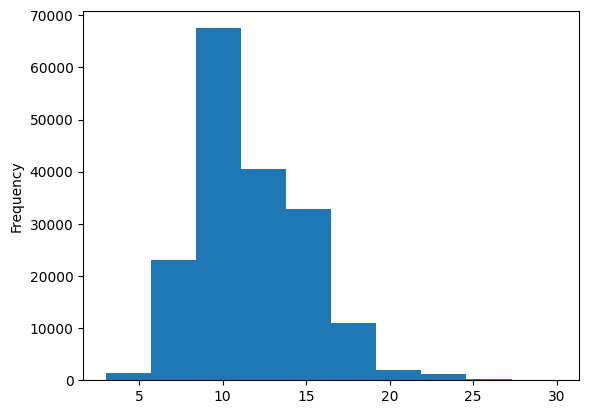

In [16]:
# Distribution of Abstract Lengths:
train_df['Total_Lines'].plot.hist()

### Get lists of sentences

When we build our deep learning model, one of its main inputs will be a list of strings (the lines of an abstract).

We can get these easily from our DataFrames by calling the `tolist()` method on our `"text"` columns.

In [17]:
# Converting Abstract Text Lines into Lists:
train_sentences = train_df['Text'].to_list()
val_sentences = val_df['Text'].to_list()
test_sentences = test_df['Text'].to_list()

In [18]:
len(train_sentences), len(val_sentences), len(test_sentences)

(180040, 30212, 30135)

In [19]:
train_sentences[:10]

['to investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( oa ) .',
 'a total of @ patients with primary knee oa were randomized @:@ ; @ received @ mg/day of prednisolone and @ received placebo for @ weeks .',
 'outcome measures included pain reduction and improvement in function scores and systemic inflammation markers .',
 'pain was assessed using the visual analog pain scale ( @-@ mm ) .',
 'secondary outcome measures included the western ontario and mcmaster universities osteoarthritis index scores , patient global assessment ( pga ) of the severity of knee oa , and @-min walk distance ( @mwd ) .',
 'serum levels of interleukin @ ( il-@ ) , il-@ , tumor necrosis factor ( tnf ) - , and high-sensitivity c-reactive protein ( hscrp ) were measured .',
 'there was a clinic

## Make numeric labels (ML models require numeric labels)

We're going to create one hot and label encoded labels.

We could get away with just making label encoded labels, however, TensorFlow's CategoricalCrossentropy loss function likes to have one hot encoded labels (this will enable us to use label smoothing later on).

To numerically encode labels we'll use Scikit-Learn's [`OneHotEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) and [`LabelEncoder`](http://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html) classes.

In [20]:
# One Hot Encoding Lables:

from sklearn.preprocessing import OneHotEncoder
one_hot_encoder = OneHotEncoder(sparse_output= False)

train_labels_one_hot = one_hot_encoder.fit_transform(train_df['Target'].to_numpy().reshape(-1, 1))
val_labels_one_hot = one_hot_encoder.fit_transform(val_df['Target'].to_numpy().reshape(-1, 1))
test_labels_one_hot = one_hot_encoder.fit_transform(test_df['Target'].to_numpy().reshape(-1, 1))

In [21]:
train_labels_one_hot

array([[0., 0., 0., 1., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 1., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.]])

In [22]:
test_labels_one_hot

array([[1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       ...,
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0.]])

In [23]:
val_labels_one_hot

array([[1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.]])

### Label encode labels

In [24]:
# Extract labels ("target" columns) and encode them into integers:

from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

train_labels_encoded = label_encoder.fit_transform(train_df['Target'].to_numpy())
val_labels_encoded = label_encoder.fit_transform(val_df['Target'].to_numpy())
test_labels_encoded = label_encoder.fit_transform(test_df['Target'].to_numpy())

In [25]:
train_labels_encoded

array([3, 2, 2, ..., 4, 1, 1])

In [26]:
test_labels_encoded

array([0, 4, 4, ..., 4, 4, 1])

In [27]:
val_labels_encoded

array([0, 0, 3, ..., 4, 1, 1])

In [28]:
# Get class names and number of classes from LabelEncoder instance:
num_classes = len(label_encoder.classes_)
class_names = label_encoder.classes_
num_classes, class_names

(5,
 array(['BACKGROUND', 'CONCLUSIONS', 'METHODS', 'OBJECTIVE', 'RESULTS'],
       dtype=object))

## Creating a series of model experiments

We've proprocessed our data so now, in true machine learning fashion, it's time to setup a series of modelling experiments.

We'll start by creating a simple baseline model to obtain a score we'll try to beat by building more and more complex models as we move towards replicating the sequence model outlined in [*Neural networks for joint sentence
classification in medical paper abstracts*](https://arxiv.org/pdf/1612.05251.pdf).

For each model, we'll train it on the training data and evaluate it on the validation data.

## Model 0: Getting a baseline 

Our first model we'll be a TF-IDF Multinomial Naive Bayes as recommended by [Scikit-Learn's machine learning map](https://scikit-learn.org/stable/tutorial/machine_learning_map/index.html).

To build it, we'll create a Scikit-Learn `Pipeline` which uses the [`TfidfVectorizer`](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html) class to convert our abstract sentences to numbers using the TF-IDF (term frequency-inverse document frequecy) algorithm and then learns to classify our sentences using the [`MultinomialNB`](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.MultinomialNB.html) aglorithm.

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

In [30]:
# Creating a Pipeline for Tf-IDF Vectorization of text and Creating The Model:
model_0 = Pipeline([
    ('Tf-Idf', TfidfVectorizer()),
    ('Classifier', MultinomialNB())
])

In [31]:
# Fitting The Model on Training Data:
model_0.fit(train_sentences, train_labels_encoded)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('Tf-Idf', ...), ('Classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [32]:
# Evaluating The Model Based on Validation Data:
model_0.score(X= val_sentences,
             y= val_labels_encoded)

0.7218323844829869

In [33]:
# Making Predictions Using Baseline Model:
baseline_preds = model_0.predict(X= val_sentences)
baseline_preds

array([4, 1, 3, ..., 4, 4, 1])

To evaluate our baseline's predictions, we'll import the `calculate_results()` function we created in the [previous notebook](https://github.com/mrdbourke/tensorflow-deep-learning/blob/main/08_introduction_to_nlp_in_tensorflow.ipynb) and added it to our [`helper_functions.py` script](https://github.com/mrdbourke/tensorflow-deep-learning/blob/main/extras/helper_functions.py) to compare them to the ground truth labels.

More specificially the `calculate_results()` function will help us obtain the following:
* Accuracy
* Precision
* Recall
* F1-score

In [34]:
# Run the below lines if helper functions are not already downloaded:
# Downloading Helper Functions:

#import wget
#url = 'https://raw.githubusercontent.com/Shailya777/Learning-Logs/refs/heads/main/Deep_Learning_with_Tensorflow/helper_functions.py'
#file = wget.download(url)

In [35]:
from helper_functions import calculate_results

2026-02-17 13:08:33.514486: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-17 13:08:33.614925: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-17 13:08:35.842308: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [36]:
# Calculating Results for Baseline Model:
baseline_results = calculate_results(y_true= val_labels_encoded,
                                    y_pred= baseline_preds)
baseline_results

{'accuracy': 72.1832384482987,
 'precision': 0.7186466952323352,
 'recall': 0.7218323844829869,
 'f1': 0.6989250353450294}

## Preparing our data for deep sequence models

Before we start building deeper models, we've got to create vectorization and embedding layers.

The vectorization layer will convert our text to numbers and the embedding layer will capture the relationships between those numbers.

To start creating our vectorization and embedding layers, we'll need to import the appropriate libraries (namely TensorFlow and NumPy).

In [37]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Input, Conv1D, Dense, LSTM, GRU, TextVectorization, Embedding
from tensorflow.keras.layers import GlobalAveragePooling1D, GlobalMaxPool1D, Bidirectional
from tensorflow.keras.layers import Concatenate, Dropout
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.optimizers import Adam

Since we'll be turning our sentences into numbers, it's a good idea to figure out how many words are in each sentence.

When our model goes through our sentences, it works best when they're all the same length (this is important for creating batches of the same size tensors).

For example, if one sentence is eight words long and another is 29 words long, we want to pad the eight word sentence with zeros so it ends up being the same length as the 29 word sentence.

In [38]:
# How Long is Each Sentence on Average?:
sent_lens = [len(sentence.split()) for sentence in train_sentences]
avg_sent_lens = np.mean(sent_lens)
avg_sent_lens

26.338269273494777

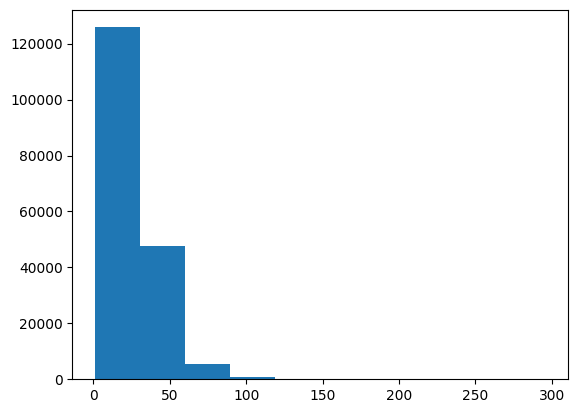

In [39]:
# Distribution of Sentence Lengths in Training Data:
import matplotlib.pyplot as plt
plt.hist(sent_lens)
plt.show()

We can use NumPy's [`percentile`](https://numpy.org/doc/stable/reference/generated/numpy.percentile.html) to find the value which covers 95% of the sentence lengths.

In [40]:
# How long of a sentence covers 95% of the lengths?:
output_seq_len = int(np.percentile(sent_lens, 95))
output_seq_len

55

It looks like 95% of the sentences in our training set have a length of 55 tokens or less.

When we create our tokenization layer, we'll use this value to turn all of our sentences into the same length. Meaning sentences with a length below 55 get padded with zeros and sentences with a length above 55 get truncated (words after 55 get cut off).

> 🤔 **Question:** Why 95%?

We could use the max sentence length of the sentences in the training set.

In [41]:
max(sent_lens)

296

However, since hardly any sentences even come close to the max length, it would mean the majority of the data we pass to our model would be zeros (sinces all sentences below the max length would get padded with zeros).

> 🔑 **Note:** The steps we've gone through are good practice when working with a text corpus for a NLP problem. You want to know how long your samples are and what the distribution of them is. See section 4 Data Analysis of the [PubMed 200k RCT paper](https://arxiv.org/pdf/1710.06071.pdf) for further examples.

### Create text vectorizer

Now we've got a little more information about our texts, let's create a way to turn it into numbers.

To do so, we'll use the [`TextVectorization`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/TextVectorization) layer from TensorFlow.

We'll keep all the parameters default except for `max_tokens` (the number of unique words in our dataset) and `output_sequence_length` (our desired output length for each vectorized sentence).

Section 3.2 of the [PubMed 200k RCT paper](https://arxiv.org/pdf/1710.06071.pdf) states the vocabulary size of the PubMed 20k dataset as 68,000. So we'll use that as our `max_tokens` parameter.

And since discovered a sentence length of 55 covers 95% of the training sentences, we'll use that as our `output_sequence_length` parameter.

In [42]:
# How many words are in our vocabulary? (taken from 3.2 in https://arxiv.org/pdf/1710.06071.pdf)
max_tokens = 68000

In [43]:
# Creating a TextVectorizer:
text_vectorizer = TextVectorization(max_tokens= max_tokens,  # number of words in vocabulary
                                   output_sequence_length= 55) # desired output length of vectorized sequences

I0000 00:00:1771333718.863944    2895 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9507 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4080 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [44]:
# Adapt Text Vectorizer to Training Sentences:
text_vectorizer.adapt(train_sentences)

In [45]:
# Testting text Vectorizer:
import random
random_sentence = random.choice(train_sentences)
print(f'Original Text: {random_sentence}')
print(f'Length of Original Text: {len(random_sentence.split())}')
print(f'Vectorized Text:\n {text_vectorizer([random_sentence])}')

Original Text: in this study , patients ' sex and mean age were examined in terms of frequency of complications of hematoma , wound infection , recurrence , itching , and duration of hospitalization and the presence of seroma , there is no significant difference between the two methods of primary surgical repair and rotation flap ( p > @ ) but in terms of the opening of the surgical wound , in primary surgical method , @ patients ( @ % ) , wound dehiscence were reported , in rotation flap , any case of wound dehiscence were reported .
Length of Original Text: 99
Vectorized Text:
 [[   5   23   17   12  693    3   57  103    9  437    5  614    4  400
     4  296    4 4489  737  360  552 5906    3  282    4  843    3    2
   797    4 5324   61   20   33   37   74   30    2   51  578    4   56
   306  958    3 3070 2910   14   72    5  614    4    2 3170    4]]


In [46]:
# How many words in training vocabulary?:
rct_20k_text_vocab = text_vectorizer.get_vocabulary()
print(f'Number of Words in Vocabulary: {len(rct_20k_text_vocab)}')
print(f'Most Common 5 Words in Vocabulary:\n {rct_20k_text_vocab[:5]}')
print(f'Least Common 5 Words in Vocabulay:\n {rct_20k_text_vocab[-5:]}')

Number of Words in Vocabulary: 64841
Most Common 5 Words in Vocabulary:
 ['', '[UNK]', 'the', 'and', 'of']
Least Common 5 Words in Vocabulay:
 ['aainduced', 'aaigroup', 'aachener', 'aachen', 'aaacp']


In [47]:
# Get the config of our text vectorizer:
text_vectorizer.get_config()

{'name': 'text_vectorization',
 'trainable': True,
 'dtype': 'string',
 'batch_input_shape': (None,),
 'max_tokens': 68000,
 'standardize': 'lower_and_strip_punctuation',
 'split': 'whitespace',
 'ngrams': None,
 'output_mode': 'int',
 'output_sequence_length': 55,
 'pad_to_max_tokens': False,
 'sparse': False,
 'ragged': False,
 'vocabulary': None,
 'idf_weights': None,
 'encoding': 'utf-8',
 'vocabulary_size': 64841}

### Create custom text embedding

Our `token_vectorization` layer maps the words in our text directly to numbers. However, this doesn't necessarily capture the relationships between those numbers.

To create a richer numerical representation of our text, we can use an **embedding**.

As our model learns (by going through many different examples of abstract sentences and their labels), it'll update its embedding to better represent the relationships between tokens in our corpus.

We can create a trainable embedding layer using TensorFlow's [`Embedding`](https://www.tensorflow.org/tutorials/text/word_embeddings) layer.

Once again, the main parameters we're concerned with here are the inputs and outputs of our `Embedding` layer.

The `input_dim` parameter defines the size of our vocabulary. And the `output_dim` parameter defines the dimension of the embedding output.

Once created, our embedding layer will take the integer outputs of our `text_vectorization` layer as inputs and convert them to feature vectors of size `output_dim`.

In [55]:
# Creating Token Embedding Layer:
token_embed = Embedding(input_dim= len(rct_20k_text_vocab), # length of vocabulary
                       output_dim= 128, # Note: different embedding sizes result in drastically different numbers of parameters to train
                       mask_zero= True, # Use masking to handle variable sequence lengths (save space)
                       name= 'Token_Embedding')

In [56]:
# Sample Embedding:
print(f'Sentence Before Vectorization:\n {random_sentence}\n')
print(f'Sentence After Vectorization(Before Embedding): \n {text_vectorizer([random_sentence])}')
print(f'Sentence After Embedding:\n {token_embed(text_vectorizer([random_sentence]))}')
print(f'Shape of Embedded Sentence: {token_embed(text_vectorizer([random_sentence])).shape}')

Sentence Before Vectorization:
 in this study , patients ' sex and mean age were examined in terms of frequency of complications of hematoma , wound infection , recurrence , itching , and duration of hospitalization and the presence of seroma , there is no significant difference between the two methods of primary surgical repair and rotation flap ( p > @ ) but in terms of the opening of the surgical wound , in primary surgical method , @ patients ( @ % ) , wound dehiscence were reported , in rotation flap , any case of wound dehiscence were reported .

Sentence After Vectorization(Before Embedding): 
 [[   5   23   17   12  693    3   57  103    9  437    5  614    4  400
     4  296    4 4489  737  360  552 5906    3  282    4  843    3    2
   797    4 5324   61   20   33   37   74   30    2   51  578    4   56
   306  958    3 3070 2910   14   72    5  614    4    2 3170    4]]
Sentence After Embedding:
 [[[-9.1953874e-03  9.8718517e-03  4.2060900e-02 ... -7.5912587e-03
   -2.184819

## Create datasets (as fast as possible)
​
We've gone through all the trouble of preprocessing our datasets to be used with a machine learning model, however, there are still a few steps we can use to make them work faster with our models.
​
Namely, the `tf.data` API provides methods which enable faster data loading.
​
> 📖 **Resource:** For best practices on data loading in TensorFlow, check out the following:
* [tf.data: Build TensorFlow input pipelines](https://www.tensorflow.org/guide/data)
* [Better performance with the tf.data API](https://www.tensorflow.org/guide/data_performance)
​
The main steps we'll want to use with our data is to turn it into a `PrefetchDataset` of batches.
​
Doing so we'll ensure TensorFlow loads our data onto the GPU as fast as possible, in turn leading to faster training time.
​
To create a batched `PrefetchDataset` we can use the methods [`batch()`](https://www.tensorflow.org/api_docs/python/tf/data/Dataset#batch) and [`prefetch()`](https://www.tensorflow.org/api_docs/python/tf/data/Dataset#prefetch), the parameter [`tf.data.AUTOTUNE`](https://www.tensorflow.org/api_docs/python/tf/data#AUTOTUNE) will also allow TensorFlow to determine the optimal amount of compute to use to prepare datasets.

In [57]:
# Turn our data into TensorFlow Datasets:
train_dataset = tf.data.Dataset.from_tensor_slices((train_sentences, train_labels_one_hot))
val_dataset = tf.data.Dataset.from_tensor_slices((val_sentences, val_labels_one_hot))
test_dataset = tf.data.Dataset.from_tensor_slices((test_sentences, test_labels_one_hot))

In [58]:
train_dataset

<_TensorSliceDataset element_spec=(TensorSpec(shape=(), dtype=tf.string, name=None), TensorSpec(shape=(5,), dtype=tf.float64, name=None))>

In [59]:
# Take the TensorSliceDatasets and turn them into prefetched batches:
train_dataset = train_dataset.batch(32).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(32).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

In [60]:
train_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None,), dtype=tf.string, name=None), TensorSpec(shape=(None, 5), dtype=tf.float64, name=None))>

## Model 1: Conv1D with token embeddings

We've now got a way to numerically represent our text and labels, time to build a series of deep models to try and improve upon our baseline.

All of our deep models will follow a similar structure:

```
Input (text) -> Tokenize -> Embedding -> Layers -> Output (label probability)
```

The main component we'll be changing throughout is the `Layers` component. Because any modern deep NLP model requires text to be converted into an embedding before meaningful patterns can be discovered within.

The first model we're going to build is a 1-dimensional Convolutional Neural Network. 

We're also going to be following the standard machine learning workflow of:
- Build model
- Train model
- Evaluate model (make predictions and compare to ground truth)

In [61]:
# Creating 1D Convolution Model for Sequence (Text) Data:

inputs = Input(shape= (1, ), dtype= tf.string)
x = text_vectorizer(inputs) # vectorize text inputs
x = token_embed(x) # create embedding
x = Conv1D(filters= 64,
          kernel_size= 5,
          padding= 'same',
          activation= 'relu')(x)
x = GlobalAveragePooling1D()(x) # condense the output of our feature vector
outputs = Dense(units= num_classes,
                activation= 'softmax')(x)

model_1 = Model(inputs, outputs)

In [62]:
# Compiling The Model:
model_1.compile(optimizer= Adam(),
               loss= CategoricalCrossentropy(),
               metrics= ['accuracy'])

In [63]:
# Model Summary:
model_1.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 1)]               0         
                                                                 
 text_vectorization (TextVe  (None, 55)                0         
 ctorization)                                                    
                                                                 
 Token_Embedding (Embedding  (None, 55, 128)           8299648   
 )                                                               
                                                                 
 conv1d (Conv1D)             (None, 55, 64)            41024     
                                                                 
 global_average_pooling1d (  (None, 64)                0         
 GlobalAveragePooling1D)                                         
                                                             

Checking out the model summary, you'll notice the majority of the trainable parameters are within the embedding layer. If we were to increase the size of the embedding (by increasing the `output_dim` parameter of the `Embedding` layer), the number of trainable parameters would increase dramatically.

It's time to fit our model to the training data but we're going to make a mindful change.

Since our training data contains nearly 200,000 sentences, fitting a deep model may take a while even with a GPU. So to keep our experiments swift, we're going to run them on a subset of the training dataset.

More specifically, we'll only use the first 10% of batches (about 18,000 samples) of the training set to train on and the first 10% of batches from the validation set to validate on.

> 🔑 **Note:** It's a standard practice in machine learning to test your models on smaller subsets of data first to make sure they work before scaling them to larger amounts of data. You should aim to run many smaller experiments rather than only a handful of large experiments. And since your time is limited, one of the best ways to run smaller experiments is to reduce the amount of data you're working with (10% of the full dataset is usually a good amount, as long as it covers a similar distribution).

In [64]:
# Fitting The Model:

model_1_history = model_1.fit(x= train_dataset,
                             validation_data= val_dataset,
                             epochs= 3,
                             steps_per_epoch= int(0.1 * len(train_dataset)), # only fit on 10% of batches for faster training time
                             validation_steps= int(0.1 * len(val_dataset))) # only validate on 10% of batches

Epoch 1/3


2026-02-17 13:18:25.384453: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91701
2026-02-17 13:18:26.396415: I external/local_xla/xla/service/service.cc:163] XLA service 0x79b415361610 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-02-17 13:18:26.396458: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4080 Laptop GPU, Compute Capability 8.9
2026-02-17 13:18:26.451753: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1771334306.959835    3049 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


562/562 [==============================] - 30s 47ms/step - loss: 0.9143 - accuracy: 0.6413 - val_loss: 0.6854 - val_accuracy: 0.7397
Epoch 2/3
562/562 [==============================] - 9s 17ms/step - loss: 0.6561 - accuracy: 0.7583 - val_loss: 0.6281 - val_accuracy: 0.7766
Epoch 3/3
562/562 [==============================] - 8s 13ms/step - loss: 0.6138 - accuracy: 0.7776 - val_loss: 0.5904 - val_accuracy: 0.7872


In [65]:
# Evaluate on whole validation dataset (we only validated on 10% of batches during training):
model_1.evaluate(val_dataset)

945/945 [==============================] - 8s 9ms/step - loss: 0.5920 - accuracy: 0.7894


[0.5919893980026245, 0.7893882989883423]

In [66]:
# Make predictions (our model outputs prediction probabilities for each class):
model_1_pred_probs = model_1.predict(val_dataset)
model_1_pred_probs[:10]

945/945 [==============================] - 16s 16ms/step


array([[4.5909777e-01, 1.6735195e-01, 7.5612359e-02, 2.5951484e-01,
        3.8423043e-02],
       [4.2864195e-01, 3.1042072e-01, 1.1164782e-02, 2.4175082e-01,
        8.0217104e-03],
       [1.3846703e-01, 5.2467999e-03, 2.2779824e-03, 8.5396409e-01,
        4.4097407e-05],
       [7.1409227e-06, 2.3841414e-04, 9.8803294e-01, 7.7939903e-06,
        1.1713738e-02],
       [8.0111751e-04, 4.0189564e-02, 3.4409013e-01, 4.6511294e-04,
        6.1445409e-01],
       [2.0484198e-02, 2.8639980e-02, 5.4794407e-01, 8.4087905e-03,
        3.9452302e-01],
       [3.8936880e-04, 4.3686512e-03, 2.7126980e-01, 1.4839185e-04,
        7.2382379e-01],
       [3.1389091e-02, 2.8228702e-02, 6.3236320e-01, 1.4405513e-02,
        2.9361349e-01],
       [2.2735392e-13, 1.2283466e-08, 1.1769057e-07, 3.7656930e-14,
        9.9999988e-01],
       [6.3807475e-03, 6.2421554e-01, 4.8373461e-02, 1.6332887e-02,
        3.0469736e-01]], dtype=float32)

In [67]:
# Converting The Model Prediction Probabilities to Labels:
model_1_preds = tf.argmax(model_1_pred_probs, axis= 1)
model_1_preds

<tf.Tensor: shape=(30212,), dtype=int64, numpy=array([0, 0, 3, ..., 4, 1, 1])>

In [68]:
# Calculate Model 1 Results:
model_1_results = calculate_results(y_true= val_labels_encoded,
                                   y_pred= model_1_preds)
model_1_results

{'accuracy': 78.93883225208526,
 'precision': 0.7859345846140308,
 'recall': 0.7893883225208527,
 'f1': 0.7868891709818854}

## Model 2: Feature extraction with pretrained token embeddings

Training our own embeddings took a little while to run, slowing our experiments down.

Since we're moving towards replicating the model architecture in [*Neural Networks for Joint Sentence Classification
in Medical Paper Abstracts*](https://arxiv.org/pdf/1612.05251.pdf), it mentions they used a [pretrained GloVe embedding](https://nlp.stanford.edu/projects/glove/) as a way to initialise their token embeddings.

To emulate this, let's see what results we can get with the [pretrained Universal Sentence Encoder embeddings from TensorFlow Hub](https://www.kaggle.com/models/google/universal-sentence-encoder/tensorFlow2/universal-sentence-encoder/2).

> 🔑 **Note:** We could use GloVe embeddings as per the paper but since we're working with TensorFlow, we'll use what's available from TensorFlow Hub (GloVe embeddings aren't). We'll save [using pretrained GloVe embeddings](https://keras.io/examples/nlp/pretrained_word_embeddings/) as an extension.

The model structure will look like:

```
Inputs (string) -> Pretrained embeddings from TensorFlow Hub (Universal Sentence Encoder) -> Layers -> Output (prediction probabilities)
```

You'll notice the lack of tokenization layer we've used in a previous model. This is because the Universal Sentence Encoder (USE) takes care of tokenization for us.

This type of model is called transfer learning, or more specifically, **feature extraction transfer learning**. In other words, taking the patterns a model has learned elsewhere and applying it to our own problem.

![TensorFlow Hub Universal Feature Encoder feature extractor model we're building](https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/main/images/09-model-tf-hub-USE-to-dense-layer.png)
*The feature extractor model we're building using a pretrained embedding from TensorFlow Hub.*

To download the pretrained USE into a layer we can use in our model, we can use the [`hub.KerasLayer`](https://www.tensorflow.org/hub/api_docs/python/hub/KerasLayer) class.

We'll keep the pretrained embeddings frozen (by setting `trainable=False`) and add a trainable couple of layers on the top to tailor the model outputs to our own data.

> 🔑 **Note:** Due to having to download a relatively large model (~916MB), the cell below may take a little while to run.

In [69]:
# Download pretrained TensorFlow Hub USE
import tensorflow_hub as hub
tf_hub_embedding_layer = hub.KerasLayer(handle= 'https://www.kaggle.com/models/google/universal-sentence-encoder/tensorFlow2/universal-sentence-encoder/2',
                                       trainable= False,
                                       name= 'Universal_Sentence_Encoder')

/home/shail/miniconda3/envs/tf-gpu/lib/python3.11/site-packages/tensorflow_hub/__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version
/home/shail/miniconda3/envs/tf-gpu/lib/python3.11/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [70]:
# Test out the embedding on a random sentence
random_sentence = random.choice(train_sentences)
print(f'Random Training Sentence:\n {random_sentence}')
random_sentence_embedded = tf_hub_embedding_layer([random_sentence])
print(f'Sentence After Embedding:\n {random_sentence_embedded[0][:30]}')
print(f'Shape of Embedded Sentence:\n {random_sentence_embedded.shape}')

Random Training Sentence:
 we determined aphasia type and quantitatively assessed speech in scores which reflected the severity of speech impairment .
Sentence After Embedding:
 [ 0.01735312 -0.00910137 -0.03938121  0.02875334 -0.00692901 -0.00885939
 -0.02177344 -0.00212332  0.07384319  0.07436355  0.07033873  0.07992769
 -0.0515576   0.06910992 -0.06811057 -0.0814478  -0.01338017  0.04969328
  0.00023396 -0.05719358  0.03933443  0.05275881 -0.07780081  0.05944378
 -0.08031377  0.05163054  0.05539456  0.00517427 -0.02262195  0.02068385]
Shape of Embedded Sentence:
 (1, 512)


### Building and fitting an NLP feature extraction model from TensorFlow Hub

In [71]:
# Creating Feature Extractor Model using Tf Hub Pre-Trained Model:

inputs = Input(shape= [], dtype= tf.string)
x= tf_hub_embedding_layer(inputs) # tokenize text and create embedding
x= Dense(units= 128, activation= 'relu')(x) # add a fully connected layer on top of the embedding
outputs = Dense(units= num_classes, activation= 'softmax')(x)

model_2 = Model(inputs, outputs)

In [72]:
# Compiling The Model:
model_2.compile(optimizer= Adam(),
               loss= CategoricalCrossentropy(),
               metrics= ['accuracy'])

In [73]:
# Summary of The Model:
model_2.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None,)]                 0         
                                                                 
 Universal_Sentence_Encoder  (None, 512)               256797824 
  (KerasLayer)                                                   
                                                                 
 dense_1 (Dense)             (None, 128)               65664     
                                                                 
 dense_2 (Dense)             (None, 5)                 645       
                                                                 
Total params: 256864133 (979.86 MB)
Trainable params: 66309 (259.02 KB)
Non-trainable params: 256797824 (979.61 MB)
_________________________________________________________________


In [74]:
# Fitting Training Data on Model 2:
model_2_history = model_2.fit(x= train_dataset,
                             validation_data= val_dataset,
                             epochs= 3,
                             steps_per_epoch= int(0.1 * len(train_dataset)),
                             validation_steps= int(0.1 * len(val_dataset)))

Epoch 1/3
562/562 [==============================] - 11s 17ms/step - loss: 0.9150 - accuracy: 0.6501 - val_loss: 0.7942 - val_accuracy: 0.6928
Epoch 2/3
562/562 [==============================] - 10s 17ms/step - loss: 0.7677 - accuracy: 0.7026 - val_loss: 0.7543 - val_accuracy: 0.7048
Epoch 3/3
562/562 [==============================] - 10s 17ms/step - loss: 0.7521 - accuracy: 0.7119 - val_loss: 0.7376 - val_accuracy: 0.7138


In [75]:
# Evaluating Model 2:
model_2.evaluate(val_dataset)

945/945 [==============================] - 14s 15ms/step - loss: 0.7403 - accuracy: 0.7143


[0.7403013706207275, 0.7143188118934631]

In [76]:
# Making Predictions with Model 2:
model_2_pred_probs = model_2.predict(val_dataset)
model_2_pred_probs[:10]

945/945 [==============================] - 13s 14ms/step


array([[4.40447032e-01, 3.49293977e-01, 2.47352943e-03, 1.98523879e-01,
        9.26158298e-03],
       [3.45946491e-01, 4.91250783e-01, 3.03294556e-03, 1.56131044e-01,
        3.63875739e-03],
       [2.57910997e-01, 1.39175281e-01, 1.81091018e-02, 5.55487454e-01,
        2.93170977e-02],
       [1.15198717e-02, 4.73433994e-02, 8.16129804e-01, 7.91321136e-03,
        1.17093757e-01],
       [3.07701305e-02, 2.57454246e-01, 1.72519147e-01, 1.16746258e-02,
        5.27581871e-01],
       [1.43869687e-03, 2.26911833e-03, 6.94924533e-01, 1.21807054e-04,
        3.01245898e-01],
       [2.36969278e-03, 3.34666134e-03, 6.83459640e-01, 1.16948679e-03,
        3.09654534e-01],
       [4.66602761e-03, 2.40227692e-02, 4.39704448e-01, 1.11082464e-03,
        5.30495942e-01],
       [5.70871576e-04, 5.73958689e-03, 1.92822386e-02, 1.25674135e-03,
        9.73150492e-01],
       [1.18178219e-01, 7.21504748e-01, 2.75281724e-02, 7.51979128e-02,
        5.75910062e-02]], dtype=float32)

In [77]:
# Converting Prediction Probabilities to Labels:
model_2_preds = tf.argmax(model_2_pred_probs, axis= 1)
model_2_preds

<tf.Tensor: shape=(30212,), dtype=int64, numpy=array([0, 1, 3, ..., 4, 4, 2])>

In [78]:
# calculating Results of Model 2:
model_2_results = calculate_results(y_true= val_labels_encoded,
                                   y_pred= model_2_preds)
model_2_results

{'accuracy': 71.4318813716404,
 'precision': 0.7150266557250379,
 'recall': 0.714318813716404,
 'f1': 0.7115232499493007}